# Storm tracking
This notebook is for running the storm tracking algorithm and creating the diagnostics plots to observe the general and individual results. For running the results you need the storm catalog output from the RaindyDay, the shapefiles of the transposition domain and control area, and the following packages.


In [2]:
#Packages:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from pyproj import Transformer # convert lat/lon to projected coordinates
from geographiclib.geodesic import Geodesic # compute storm centroid movement
import geopandas as gpd # read shapefiles
import os
import pandas as pd
import scrapbook as sb
import sys
import seaborn as sns

### Storm tracking packages
The following packages need to be in the same folder as this notebook

In [3]:
from pathlib import Path


# add project root (parent of Notebooks/) to sys.path
root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

# Import storm dataset and related modules
from functions.storm_dataset import storm_tracking_event, continuos_storm, storm_tracking_features
from functions.storm_direction import mean_precipitation_within_ellipse, get_max_accumulated_value, compute_line_length, mean_velocity, mean_direction, mean_direction_ln, mean_direction_weighted,  percentile_direction
from functions.diagnostic_plots import diagnostic_plot_storm_trajectories, diagnostic_plot_storm_direction_vectors, plot_storm_track, plot_storm_time_steps, plot_storm_trajectories

### Storm tracking parameters
Define the parameter for the storm tracking run and analysis


In [33]:
## Storm tracking parameters
morph_radius = 2 # radius for morph structure
high_treshold = 0.5 # threshold for high precipitation (in mm/hr)
storm_interval = '12H' # storm time interval for getting the most intese precipitation

## Reading control area and transposition domain shapefile
control_area_path = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/RainyDay_Runs/Run_CONUS/Shapes/control_area_circle_40.0.shp"
transposition_domain_path = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/RainyDay_Runs/Run_CONUS/Domains/Domain_40.shp"

# Read the storm catalog
#folder = run_folder +  '/Results/'+ scenario_name+'/StormCatalog/'
catalog_folder = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/RainyDay_Runs/Run_CONUS/Results/Domain_40.0_circle_10000km2/StormCatalog/"

## Set the path for the output folder and figure path
fig_path = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/CONUS_DOMAINS_V2/D3'

# Domain name
domain_name = 'Domain_40.0_circle_10000km2'

### Reading storm catalog name files

In [34]:

transposition_domain = gpd.read_file(transposition_domain_path)
# Get the list of storm events from the catalog folder
#domain_name = control_area_path.split('/')[-1].split('_')[3][:4]

event_list = os.listdir(catalog_folder)
event_list = [event for event in event_list if event.endswith('.nc')] ## filter only netcdf files
shp_path = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Projects/Cartography/CONUS_5d_grid.shp"
grid = gpd.read_file(shp_path)

### Creating folder for results and saving plots


In [25]:


# create folder for figures if it doesn't exist
fig_folder = os.path.join(fig_path, domain_name)
if not os.path.exists(fig_folder):
    os.makedirs(fig_folder)


In [35]:

#create folders for saving plots
storm_track_path = os.path.join(fig_folder, 'StormTrack')
if not os.path.exists(storm_track_path):
    os.makedirs(storm_track_path)
storm_time_timesteps_path = os.path.join(fig_folder, 'StormTimeSteps')
if not os.path.exists(storm_time_timesteps_path):
    os.makedirs(storm_time_timesteps_path)

### Running the storm tracking algorithm

In [36]:
# create dictionary to store the results
storm_tracking_results = {}

# Iterate over each event in the event_list
event_list.sort()

for event in event_list:
    # Initialize an empty dictionary for each event
    storm_tracking_results[event] = {}

for storm_event in event_list:
    ds = xr.open_dataset(os.path.join(catalog_folder, storm_event)) # Load the dataset
    print(storm_event)
    event_dict = {}
    storm_tracking_event(ds, event_dict, morph_radius=morph_radius, high_threshold=high_treshold)
    if int(event_dict['longest_duration']) <= 5: # Skip events with duration less than or equal to 5 time steps
        print(f"Skipping event {storm_event} due to short duration: {event_dict['longest_duration']} time steps.")
        continue
    continuos_storm(event_dict)
    storm_tracking_features(event_dict, ellipse_fit="Momentum")
    storm_tracking_results[storm_event] = event_dict # Store the results in the dictionary

IOWA_Domain.nc_storm_100_20220916.nc
The longest storm has a valid duration of 4 hours
The selected duration is longer than 0.1 of 24 hours
Skipping event IOWA_Domain.nc_storm_100_20220916.nc due to short duration: 4 time steps.
IOWA_Domain.nc_storm_101_20150519.nc
The longest storm has a valid duration of 23 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2015-05-19T10:00:00.000000000 to 2015-05-20T08:00:00.000000000
Selected storm duration 23 hours
IOWA_Domain.nc_storm_102_20191020.nc
The longest storm has a valid duration of 23 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2019-10-20T21:00:00.000000000 to 2019-10-21T19:00:00.000000000
Selected storm duration 23 hours
IOWA_Domain.nc_storm_103_20110702.nc
The longest storm has a valid duration of 6 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2011-07-02T09:00:00.000000000 to 2011-07-02T19:00:00.000000000
Selected stor

In [37]:
print(event_list)

['IOWA_Domain.nc_storm_100_20220916.nc', 'IOWA_Domain.nc_storm_101_20150519.nc', 'IOWA_Domain.nc_storm_102_20191020.nc', 'IOWA_Domain.nc_storm_103_20110702.nc', 'IOWA_Domain.nc_storm_104_20170915.nc', 'IOWA_Domain.nc_storm_105_20150808.nc', 'IOWA_Domain.nc_storm_106_20150705.nc', 'IOWA_Domain.nc_storm_107_20200720.nc', 'IOWA_Domain.nc_storm_108_20110726.nc', 'IOWA_Domain.nc_storm_109_20170421.nc', 'IOWA_Domain.nc_storm_10_20120203.nc', 'IOWA_Domain.nc_storm_110_20190826.nc', 'IOWA_Domain.nc_storm_111_20030508.nc', 'IOWA_Domain.nc_storm_112_20040713.nc', 'IOWA_Domain.nc_storm_113_20090809.nc', 'IOWA_Domain.nc_storm_114_20110616.nc', 'IOWA_Domain.nc_storm_115_20130915.nc', 'IOWA_Domain.nc_storm_116_20040727.nc', 'IOWA_Domain.nc_storm_117_20130621.nc', 'IOWA_Domain.nc_storm_118_20210502.nc', 'IOWA_Domain.nc_storm_119_20151002.nc', 'IOWA_Domain.nc_storm_11_20211019.nc', 'IOWA_Domain.nc_storm_120_20160719.nc', 'IOWA_Domain.nc_storm_121_20161225.nc', 'IOWA_Domain.nc_storm_122_20090626.nc', '

In [38]:
my_dict = {k: v for k, v in storm_tracking_results.items() if v}
len(my_dict)

370

In [21]:
list(my_dict.keys())

['IOWA_Domain.nc_storm_104_20220215.nc',
 'IOWA_Domain.nc_storm_107_20060303.nc',
 'IOWA_Domain.nc_storm_110_20151213.nc',
 'IOWA_Domain.nc_storm_113_20071207.nc',
 'IOWA_Domain.nc_storm_114_20121218.nc',
 'IOWA_Domain.nc_storm_123_20120207.nc',
 'IOWA_Domain.nc_storm_127_20110130.nc',
 'IOWA_Domain.nc_storm_128_20131219.nc',
 'IOWA_Domain.nc_storm_130_20070223.nc',
 'IOWA_Domain.nc_storm_131_20040218.nc',
 'IOWA_Domain.nc_storm_132_20111106.nc',
 'IOWA_Domain.nc_storm_137_20060219.nc',
 'IOWA_Domain.nc_storm_143_20190311.nc',
 'IOWA_Domain.nc_storm_148_20081225.nc',
 'IOWA_Domain.nc_storm_150_20050128.nc',
 'IOWA_Domain.nc_storm_154_20110408.nc',
 'IOWA_Domain.nc_storm_163_20120123.nc',
 'IOWA_Domain.nc_storm_165_20151004.nc',
 'IOWA_Domain.nc_storm_169_20120121.nc',
 'IOWA_Domain.nc_storm_170_20160506.nc',
 'IOWA_Domain.nc_storm_172_20061210.nc',
 'IOWA_Domain.nc_storm_175_20190925.nc',
 'IOWA_Domain.nc_storm_177_20070423.nc',
 'IOWA_Domain.nc_storm_184_20040103.nc',
 'IOWA_Domain.nc

### Computing storm's speed and direction

In [11]:
# removing empty storms events
storm_tracking_results = {k: v for k, v in storm_tracking_results.items() if v}

# list for storing the results
storm_mean_velocity = []
storm_intesity = []
storm_mean_direction_vector = []
storm_mean_direction_weighted = []
storm_area = []
dir_var_weighted = []
res_lenght = []
storm_mean_direction_lm = []
position=[]
start_time_list = []


# dictory to store the trajectories in the defined time window
storm_trajectories = {}
# Iterate over each storm event in the tracking results
for storm_event in storm_tracking_results.keys():
    storm = storm_tracking_results[storm_event]
    mean_p_ellipse = mean_precipitation_within_ellipse(storm)
    mean_p = pd.Series(mean_p_ellipse, index=storm['selected_storm_time_steps'].values)
    most_intense_interval = get_max_accumulated_value(mean_p, storm_interval)
    start_time_index = most_intense_interval[3] # start time index 
    end_time_index = most_intense_interval[4] # end time index
    if mean_p_ellipse.min() < 0:
        print(f"Warning: Negative mean precipitation values found in storm {storm_event}. Check the data.")
        continue
    # Getting the centroid coordinates for the start and end time
    x = storm['storm_prj_lon_cent_list'][start_time_index:end_time_index]
    y = storm['storm_prj_lat_cent_list'][start_time_index:end_time_index]

    # compute the length of the trajectory
    trajectory_length = compute_line_length(x, y)

    
    
    # Compute the mean velocity and direction
    v = mean_velocity(x, y)
    d,vd = mean_direction(x, y)
    wd, wv = mean_direction_weighted(x, y)
    lm = mean_direction_ln(x, y)[0]
    # Append the results to the lists
    storm_mean_velocity.append(v)
    storm_mean_direction_vector.append(d)
    storm_mean_direction_lm.append(lm)
    dir_var_weighted.append(wv)
    #res_lenght.append(r)
    storm_id = storm_event.split('_storm_')[1].split('_')[0]
    position.append(int(storm_id)) # storm ID
    storm_mean_direction_weighted.append(wd)
    start_time_list.append(storm['selected_storm_time_steps'][start_time_index].values)
    storm_area.append(storm['selected_storm_area'][start_time_index:end_time_index+1].mean())
    storm_intesity.append(mean_p_ellipse[start_time_index:end_time_index+1].mean())
    storm_trajectories[storm_event] = {
        'start_time_index': start_time_index,
        'end_time_index': end_time_index,
        'x_coords': x,
        'y_coords': y,
        'trajectory_length': trajectory_length,
        'mean_precipitation': mean_p_ellipse[start_time_index:end_time_index+1].mean(),
        'angular_variance': wv,
        'storm_id': int(storm_event.split('_storm_')[1].split('_')[0]),  # Extracting storm ID from the filename 
    }
    
    # Saving the results for each storm
    storm_tracking_results[storm_event]['mean_velocity'] = v
    storm_tracking_results[storm_event]['mean_direction'] = d
    storm_tracking_results[storm_event]['var_direction'] = vd
    storm_tracking_results[storm_event]['mean_direction_ln'] = lm
    storm_tracking_results[storm_event]['mean_direction_weighted'] = wd
    storm_tracking_results[storm_event]['var_dir_weighted'] = wv
    # Define the transformer for converting projected coordinates to geographic coordinates
transformer = Transformer.from_crs("EPSG:2163", "EPSG:4326", always_xy=True)

# Create a dictionary to store the geographic trajectories
geographic_trajectories = {}

# Iterate over each trajectory in storm_trajectories
for storm_event, traj in storm_trajectories.items():
    x_coords = traj['x_coords']
    y_coords = traj['y_coords']
    
    # Transform the coordinates
    lon_coords, lat_coords = transformer.transform(x_coords, y_coords)
    
    # Store the geographic coordinates in the dictionary
    geographic_trajectories[storm_event] = {
        'start_time_index': traj['start_time_index'],
        'end_time_index': traj['end_time_index'],
        'lon_coords': lon_coords,
        'lat_coords': lat_coords,
        'trajectory_length': traj['trajectory_length']
    }
#save the properties in dataframe
storm_properties = pd.DataFrame({
    'storm_id': position,
    'start_time': start_time_list,
    'mean_velocity': storm_mean_velocity,
    'mean_direction_vector': storm_mean_direction_vector,
    'mean_direction_lm': storm_mean_direction_lm,
    'mean_direction_weighted': storm_mean_direction_weighted,
    'angular_variance_weighted': dir_var_weighted,
    #'resultant_length': res_lenght,
    'storm_area': storm_area,
    'storm_intensity': storm_intesity

})
df = pd.DataFrame.from_dict(storm_trajectories,orient='index')

/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer/functions/storm_direction.py:186: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  window = pd.to_timedelta(window)


In [32]:
x = np.percentile(storm_properties['mean_direction_weighted'], 50)
print(x)
y = np.percentile(storm_properties['mean_direction_weighted'], 25)
print(y)

-5.151751669665123
-28.308482101696562


In [ ]:
# circullar percentiles


## Creation diagnostic plots

### Mean trajectories and direction plot

In [12]:
# Create a folder for the diagnostic plots
#diagnostic_plots_folder = os.path.join(scenario_folder, 'Diagnostic_Plots')
longest_trajectories = dict(sorted(storm_trajectories.items(), key=lambda item: item[1]['trajectory_length'], reverse=True)[:100])
mean_angle = np.degrees(np.arctan2(np.mean(np.sin(np.radians(storm_mean_direction_weighted))), 
                                       np.mean(np.cos(np.radians(storm_mean_direction_weighted))))) # mean angle of the storm trajectories
sb.glue('mean_angle', float(mean_angle)) # record the mean angle using papermill
mean_vel = np.mean(storm_mean_velocity) # mean velocity of the storm trajectories
sb.glue('mean_vel', float(mean_vel)) # record the mean velocity using papermill
mean_p = np.mean(mean_p_ellipse)
sb.glue('mean_p', float(mean_p)) # record the mean precipitation using papermill


diagnostic_plot_storm_trajectories(
    df = df, longest_trajectories= longest_trajectories, 
    geographic_trajectories = geographic_trajectories, 
    transposition_domain = transposition_domain,
    storm_mean_direction_vector = storm_mean_direction_weighted, 
    storm_mean_velocity = storm_mean_velocity, 
    mean_angle = mean_angle, mean_vel = mean_vel, 
    mean_p_ellipse = mean_p, 
    time_window =  storm_interval,
    grid=grid,
    fig_name = domain_name,
    save_path=fig_folder,
    font_size=0
    )

# Save the storm tracking results to a CSV file
tracking_results_df = pd.DataFrame.from_dict(storm_tracking_results, orient='index')
#tracking_results_df.to_csv(os.path.join(folder, 'storm_tracking_results.csv'))

/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer/functions/diagnostic_plots.py:336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


In [17]:
ongest_trajectories = dict(sorted(storm_trajectories.items(), key=lambda item: item[1]['trajectory_length'], reverse=True)[:400])
diagnostic_plot_storm_direction_vectors(
    df = df, longest_trajectories= longest_trajectories, 
    geographic_trajectories = geographic_trajectories, 
    transposition_domain = transposition_domain,
    storm_mean_direction_vector = storm_mean_direction_weighted, 
    storm_mean_velocity = storm_mean_velocity, 
    mean_angle = mean_angle, mean_vel = mean_vel, 
    mean_p_ellipse = mean_p, 
    time_window =  storm_interval,
    grid=grid,
    fig_name = domain_name,
    save_path=fig_folder,
    font_size=3,
    arrow_scale=1,
    arrow_width=0.005,
    head_length=1.5,
    head_width=2,
    colorbar_var='mean_precipitation'
    )

/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer/functions/diagnostic_plots.py:512: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


### Storm track and storm time steps for each storm in the catalog

In [48]:
# Plot storm trajectories and time steps

# for storm_track in storm_tracking_results.keys():
#     plot_storm_track(
#         storm_tracking_results = storm_tracking_results, 
#         storm_name = storm_track, 
#         storm_trajectories = storm_trajectories,
#         save_path = storm_track_path)
    
#     st = storm_trajectories[storm_track]['start_time_index']
#     en = storm_trajectories[storm_track]['end_time_index']
#     plot_storm_time_steps(storm_tracking_results=storm_tracking_results,
#                           storm_name=storm_track, start_end= (st,en),
#                           time_window=storm_interval,
#                           save_path=storm_time_timesteps_path, font_size=0)



### Pair plot of storm properties

In [45]:
### Storm stats plot

storm_mean_intesity = []
storm_area = []

for storm_event in storm_tracking_results.keys():
    storm = storm_tracking_results[storm_event]
    storm_mean_intesity.append(np.mean(storm['storm_record']['avg_prcp(mm/h)']))
    storm_area.append(np.mean(storm['selected_storm_area']))

storm_mean_intesity = np.array(storm_mean_intesity)

storm_area = np.array(storm_area)

# Create a DataFrame to hold the storm statistics
storm_stats = pd.DataFrame({
    'storm_event': list(storm_tracking_results.keys()),
    'storm_direction': storm_mean_direction_weighted,
    'storm_velocity': storm_mean_velocity,
    'mean_intensity': storm_mean_intesity,
    'angular_variance_weighted': dir_var_weighted,
    'area': storm_area
})

# Rename columns with descriptive labels + units
storm_stats_renamed = storm_stats.rename(columns={
    'storm_direction': 'Storm Direction (°)',
    'storm_velocity': 'Storm Velocity (m/s)',
    'mean_intensity': 'Mean Intensity (mm/h)',
    'area': 'Storm Area (km²)'  # adjust units if needed
})

## plot the storm statistics with pairplot
#sns.pairplot(storm_stats_renamed, diag_kind='hist', markers='o', corner=True)
plt.suptitle('Storm Statistics Pairplot', y=1.02, fontsize=16)
#plt.savefig(os.path.join(fig_path, f'storm_statistics_pairplot{domain_name}.png'), dpi=300, bbox_inches='tight')

Text(0.5, 1.02, 'Storm Statistics Pairplot')

<Figure size 640x480 with 0 Axes>

In [46]:
## pair plot storm properties with seaborn
storm_properties.rename(columns={
    'mean_direction_vector': 'Mean Direction Vector (°)',
    'mean_direction_lm': 'Mean Direction LN (°)',
    'mean_direction_weighted': 'Mean Direction(°)',
    'angular_variance_weighted': 'Angular Variance',
    'resultant_length': 'Resultant Length',
    'storm_area': 'Storm Area (km²)',
    'storm_intensity': 'Storm Intensity (mm/h)',
    'mean_velocity': 'Mean velocity (m/s)'}, 
    inplace=True)



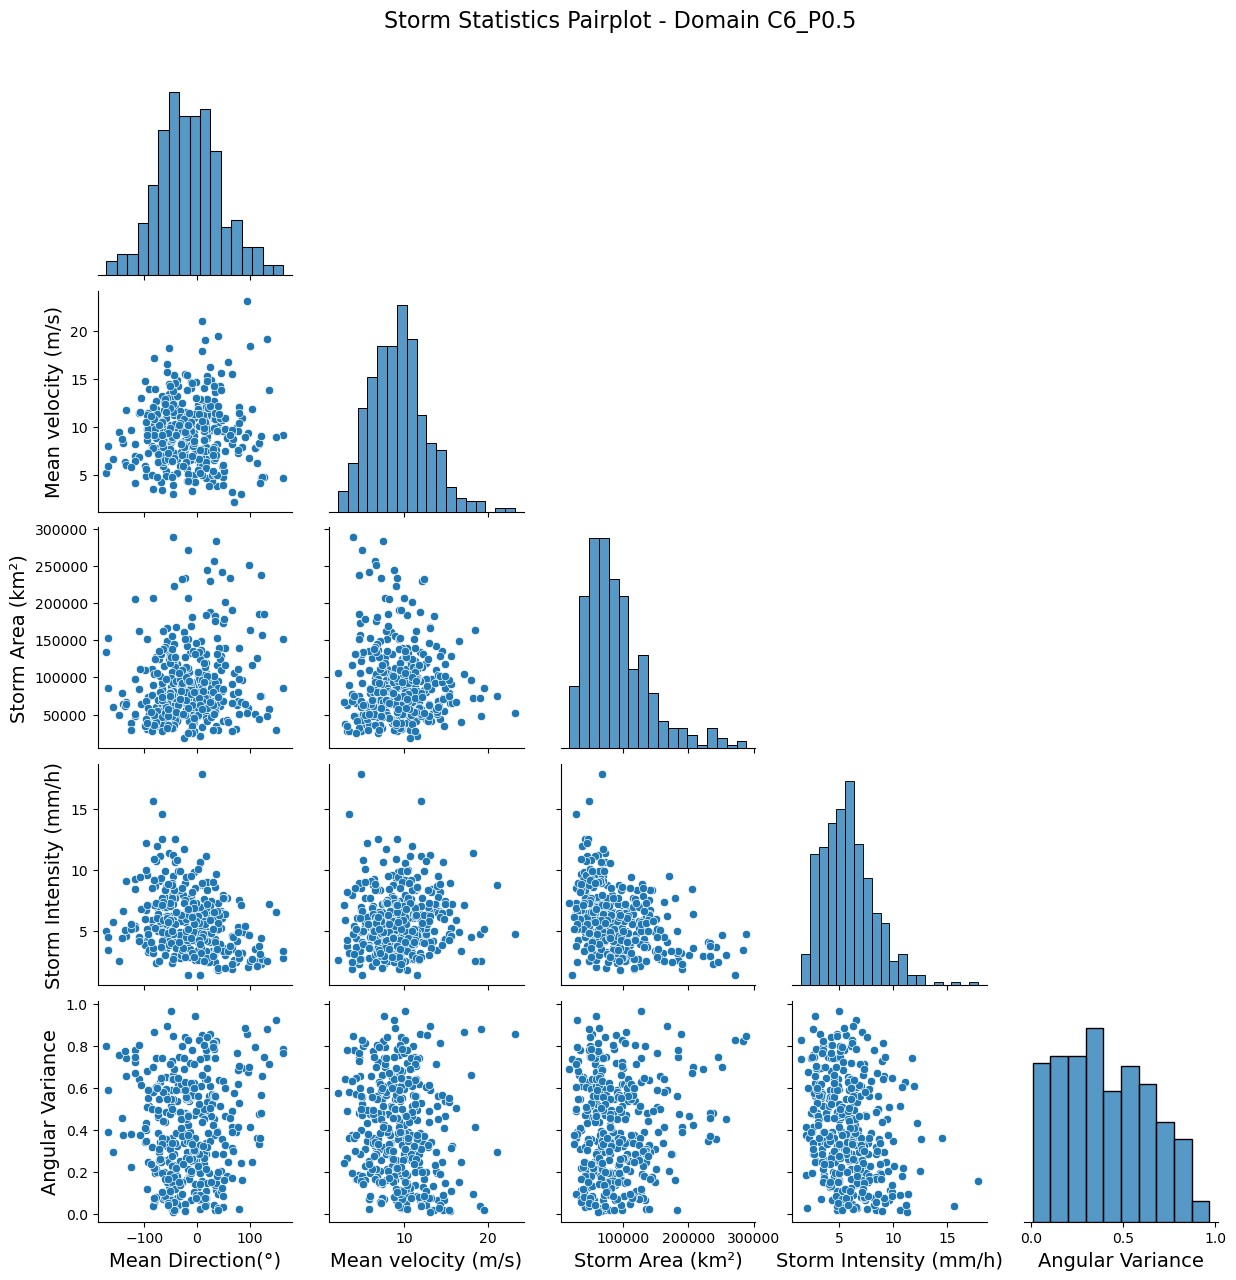

In [47]:
g =sns.pairplot(storm_properties, 
             x_vars=[ 'Mean Direction(°)', 'Mean velocity (m/s)', 'Storm Area (km²)', 'Storm Intensity (mm/h)', 'Angular Variance'],
             y_vars=['Mean Direction(°)', 'Mean velocity (m/s)', 'Storm Area (km²)', 'Storm Intensity (mm/h)', 'Angular Variance'],
             diag_kind='hist', markers='o', corner=True)

# axis labels size
# Increase axis label font size (robust across versions)
label_size = 14
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), fontsize=label_size)
        ax.set_ylabel(ax.get_ylabel(), fontsize=label_size)

plt.suptitle(f'Storm Statistics Pairplot - Domain {domain_name}', y=1.02, fontsize=16)
plt.savefig(os.path.join(fig_folder, f'storm_statistics_pairplot_{domain_name}.png'), dpi=300, bbox_inches='tight')


In [47]:
table_path = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/CONUS_storm_tracking/Storm_Tracking_Stats'
storm_stats.to_csv(os.path.join(table_path, f'storm_properties_{domain_name}.csv'), index=False)